In [51]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from matplotlib import animation
from matplotlib.colors import ListedColormap

In [52]:
def apply_bc (phi):
    phi = phi.copy()
    phi[0, :]  = 0
    phi[-1, :] = 0
    phi[:, 0]  = 0
    phi[:, -1] = 0
    return phi

def RK4 (h, x0, y0, f, n) :
    x = x0
    eta = y0.copy()

    xs = np.zeros(n+1)
    ys = np.zeros((n+1,) + y0.shape, dtype=complex)

    for i in range(n) :

        eta = apply_bc(eta)
        
        xs[i] = x
        ys[i] = eta

        k_1 = f(x, eta)
        k_2 = f(x + h/2, apply_bc(eta + h * k_1/2))
        k_3 = f(x + h/2, apply_bc(eta + h * k_2/2))
        k_4 = f(x + h, apply_bc(eta + h * k_3))

        eta = eta + h / 6 * (k_1 + 2*k_2 + 2*k_3 + k_4)
        eta = apply_bc(eta)
        x = x + h

    eta = apply_bc(eta)
    xs[n] = x
    ys[n] = eta
    
    return xs, ys

In [53]:
def H_m(phi, V, a, Ax, Ay, A2) :
    
    k = np.zeros(2)

    phi_m1_x = np.roll(phi, -1, axis=1)
    phi_p1_x = np.roll(phi, +1, axis=1)
    phi_m1_y = np.roll(phi, -1, axis=0)
    phi_p1_y = np.roll(phi, +1, axis=0)
    
    k0 = 1 / (2 * a[0]**2)
    k1 = 1 / (2 * a[1]**2)

    kinetic = - k0 * (phi_m1_x + phi_p1_x) - k1 * (phi_m1_y + phi_p1_y) + 2 * (k0 + k1) * phi

    dphidx = (phi_p1_x - phi_m1_x) / (2 * a[0])
    dphidy = (phi_p1_y - phi_m1_y) / (2 * a[1])
    paramagnetic = -1j * (Ax * dphidx + Ay * dphidy)

    diamagnetic = 0.5 * A2 * phi

    H_m = kinetic + paramagnetic + diamagnetic + V * phi
    
    return H_m

def psi0 (x, y, y0, sigma, p) :

    x0, y0 = y0
    px, py = p

    return np.exp(-((x - x0)**2 + (y - y0)**2) / sigma**2)*np.exp(1j * (px * x + py * y))

In [54]:
t_in = 0
t_fin = 0.8
delta_tau = 0.002
n_step = int(np.abs(t_in - t_fin) / delta_tau)

N = 128
mL = 8
L = mL

y0 = [L/4, L/2]
sigma_m = 0.5 
p = [(2 * np.pi) * 6 / L, 0]

delta_x = L / N
delta_y = L / N
a = [delta_x, delta_y]

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y)

#barriera di potenziale con doppia fenditura
V = np.zeros((N, N))
wall_thick = delta_x *4
mask_muro = (X >= L/2 - wall_thick) & (X <= L/2 + wall_thick)
V[mask_muro] = 100.0

centro_y1 = L/2 - 1 * sigma_m 
centro_y2 = L/2 + 1 * sigma_m 

semi_ampiezza = 2 * delta_y  
fenditura_1 = (Y >= centro_y1 - semi_ampiezza) & (Y <= centro_y1 + semi_ampiezza)
fenditura_2 = (Y >= centro_y2 - semi_ampiezza) & (Y <= centro_y2 + semi_ampiezza)

V[mask_muro & fenditura_1] = 0.0
V[mask_muro & fenditura_2] = 0.0

In [55]:
#solenoide e potenziale vettore
Phi = 0.5                        # flusso in unità di Φ0
xs = L/2 + delta_x / 2
ys = L/2 + delta_x/2
r2 = (X - xs)**2 + (Y - ys)**2

Ax, Ay = -Phi * (Y - ys) / r2, Phi * (X - xs) / r2
A2 = Ax**2 + Ay**2

r_excl = 3 * delta_x
Ax[r2 < r_excl**2] = 0.0
Ay[r2 < r_excl**2] = 0.0
A2[r2 < r_excl**2] = 0.0

In [56]:
phi0 = psi0(X, Y, y0, sigma_m, p)
norma = np.sum(np.abs(phi0)**2) * delta_x * delta_y
phi0_norm = phi0 / np.sqrt(norma)

H_m_wrapped = lambda t, phi: -1j * H_m(phi, V, a, Ax, Ay, A2)
t_values, psi_values = RK4(delta_tau, t_in, phi0_norm, H_m_wrapped, n_step)
psi_square = np.abs(psi_values) ** 2

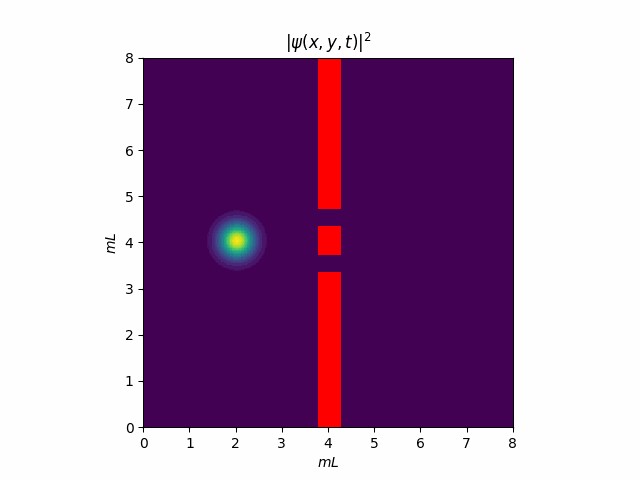

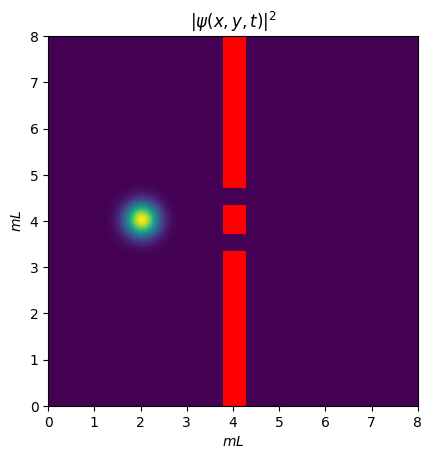

In [57]:
fig, ax = plt.subplots()
psi_square_plot = ax.imshow(psi_square[0].reshape(N, N), origin='lower', extent=[0,8,0,8])
ax.set_title(r'$|\psi(x,y,t)|^{2}$')
ax.set_xlabel(r'$mL$')
ax.set_ylabel(r'$mL$')

V_masked = np.ma.masked_where(V == 0, V)
V_plot = ax.imshow(V_masked, origin='lower', extent=[0, 8, 0, 8], cmap = ListedColormap(['red']))

def animate(i):
    psi_square_plot.set_data(psi_square[i].reshape(N, N))
    psi_square_plot.set_clim(vmin=np.min(psi_square[i]), vmax=np.max(psi_square[i]))
    return [psi_square_plot]
    
ani = animation.FuncAnimation(fig, animate, frames=len(psi_square), blit = False)
writer = animation.PillowWriter(fps=10,bitrate=1800)
ani.save(f'Double_slit_ABeffect.gif', writer=writer)

Image('Double_slit_ABeffect.gif')

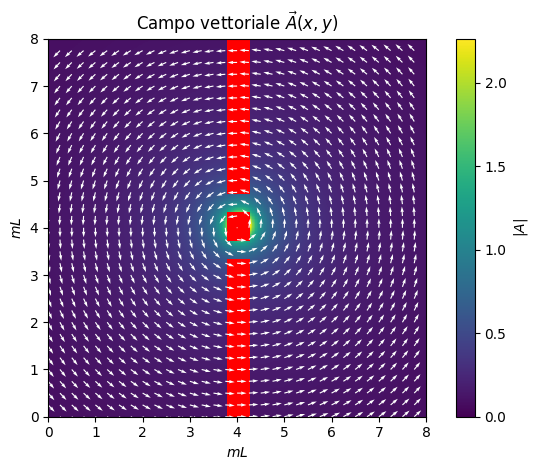

In [58]:
fig, ax = plt.subplots()

A_mag_plot = ax.imshow(np.sqrt(A2), origin='lower', extent=[0, 8, 0, 8], cmap='viridis')
ax.set_title(r'Campo vettoriale $\vec{A}(x,y)$')
ax.set_xlabel(r'$mL$')
ax.set_ylabel(r'$mL$')
fig.colorbar(A_mag_plot, ax=ax, label=r'$|A|$')

step = 4
#normalizza le frecce a lunghezza unitaria, il colore di sfondo porta l'informazione sul modulo
Ax_norm = Ax / (np.sqrt(A2) + 1e-12)
Ay_norm = Ay / (np.sqrt(A2) + 1e-12)

ax.quiver(X[::step, ::step], Y[::step, ::step],
          Ax_norm[::step, ::step], Ay_norm[::step, ::step],
          color='white', scale=40, width=0.003)

V_masked = np.ma.masked_where(V == 0, V)
ax.imshow(V_masked, origin='lower', extent=[0, 8, 0, 8], cmap=ListedColormap(['red']))

plt.tight_layout()
plt.savefig('Vector_field_A.png', dpi=150)
plt.show()

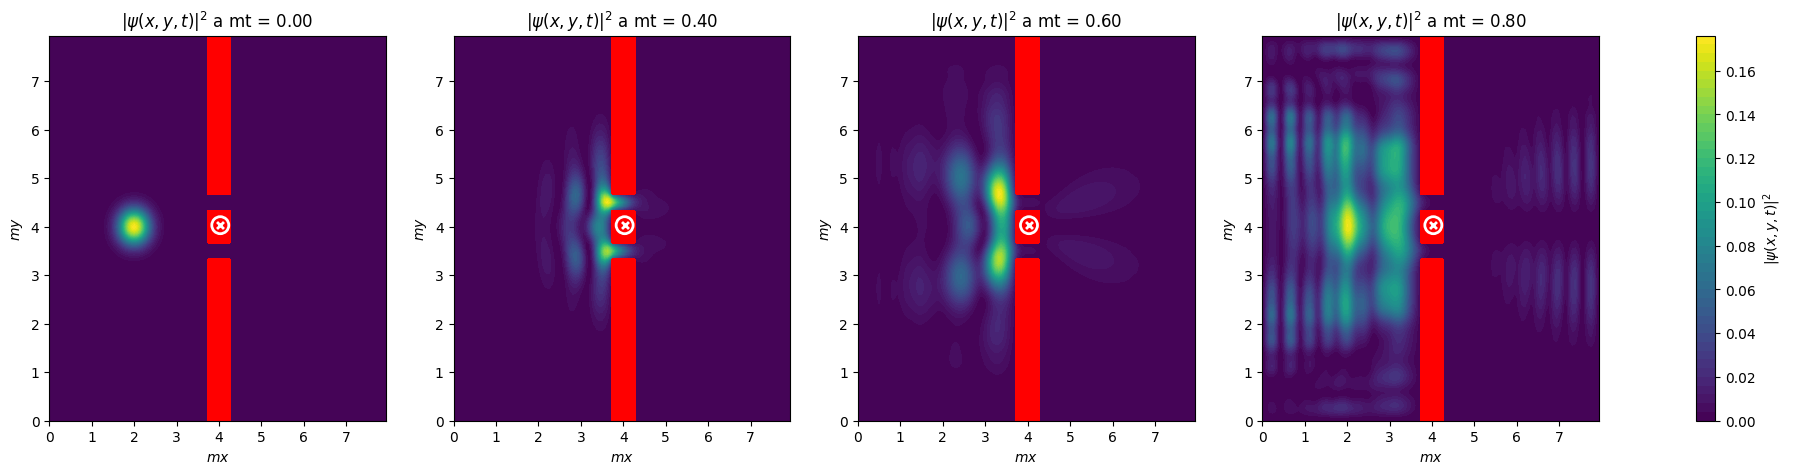

probabilità sui bordi = 0.0


In [59]:
times_to_plot = [0, 0.4, 0.6, 1]

fig, axes = plt.subplots(1, len(times_to_plot), figsize=(25,5))

for ax, t_target in zip(axes, times_to_plot):

    idx = np.argmin(np.abs(t_values - t_target))
    frame = psi_square[idx].reshape(N, N)

    contour = ax.contourf(X, Y, frame, levels=50, cmap='viridis')
    ax.contourf(X, Y, V, levels=[V.max()/2, V.max()*2], colors='red')
    ax.scatter(xs, ys, s=150, facecolors='none', edgecolors='white', linewidths=2, zorder=10)

    ax.scatter(xs, ys, s=25, color='white', marker='x', linewidths=2, zorder=11)

    ax.set_title(fr"$|\psi(x,y,t)|^2$ a mt = {t_values[idx]:.2f}")
    ax.set_xlabel('$mx$')
    ax.set_ylabel('$my$')

plt.colorbar(contour, ax=axes.ravel().tolist(), label=r'$|\psi(x,y,t)|^2$')
plt.show()

border_probability = (
    np.sum(np.abs(psi_values[:, 0, :])**2) +
    np.sum(np.abs(psi_values[:, -1, :])**2) +
    np.sum(np.abs(psi_values[:, :, 0])**2) +
    np.sum(np.abs(psi_values[:, :, -1])**2)
)

print("probabilità sui bordi =", border_probability)

posizione dello schermo:  6.375


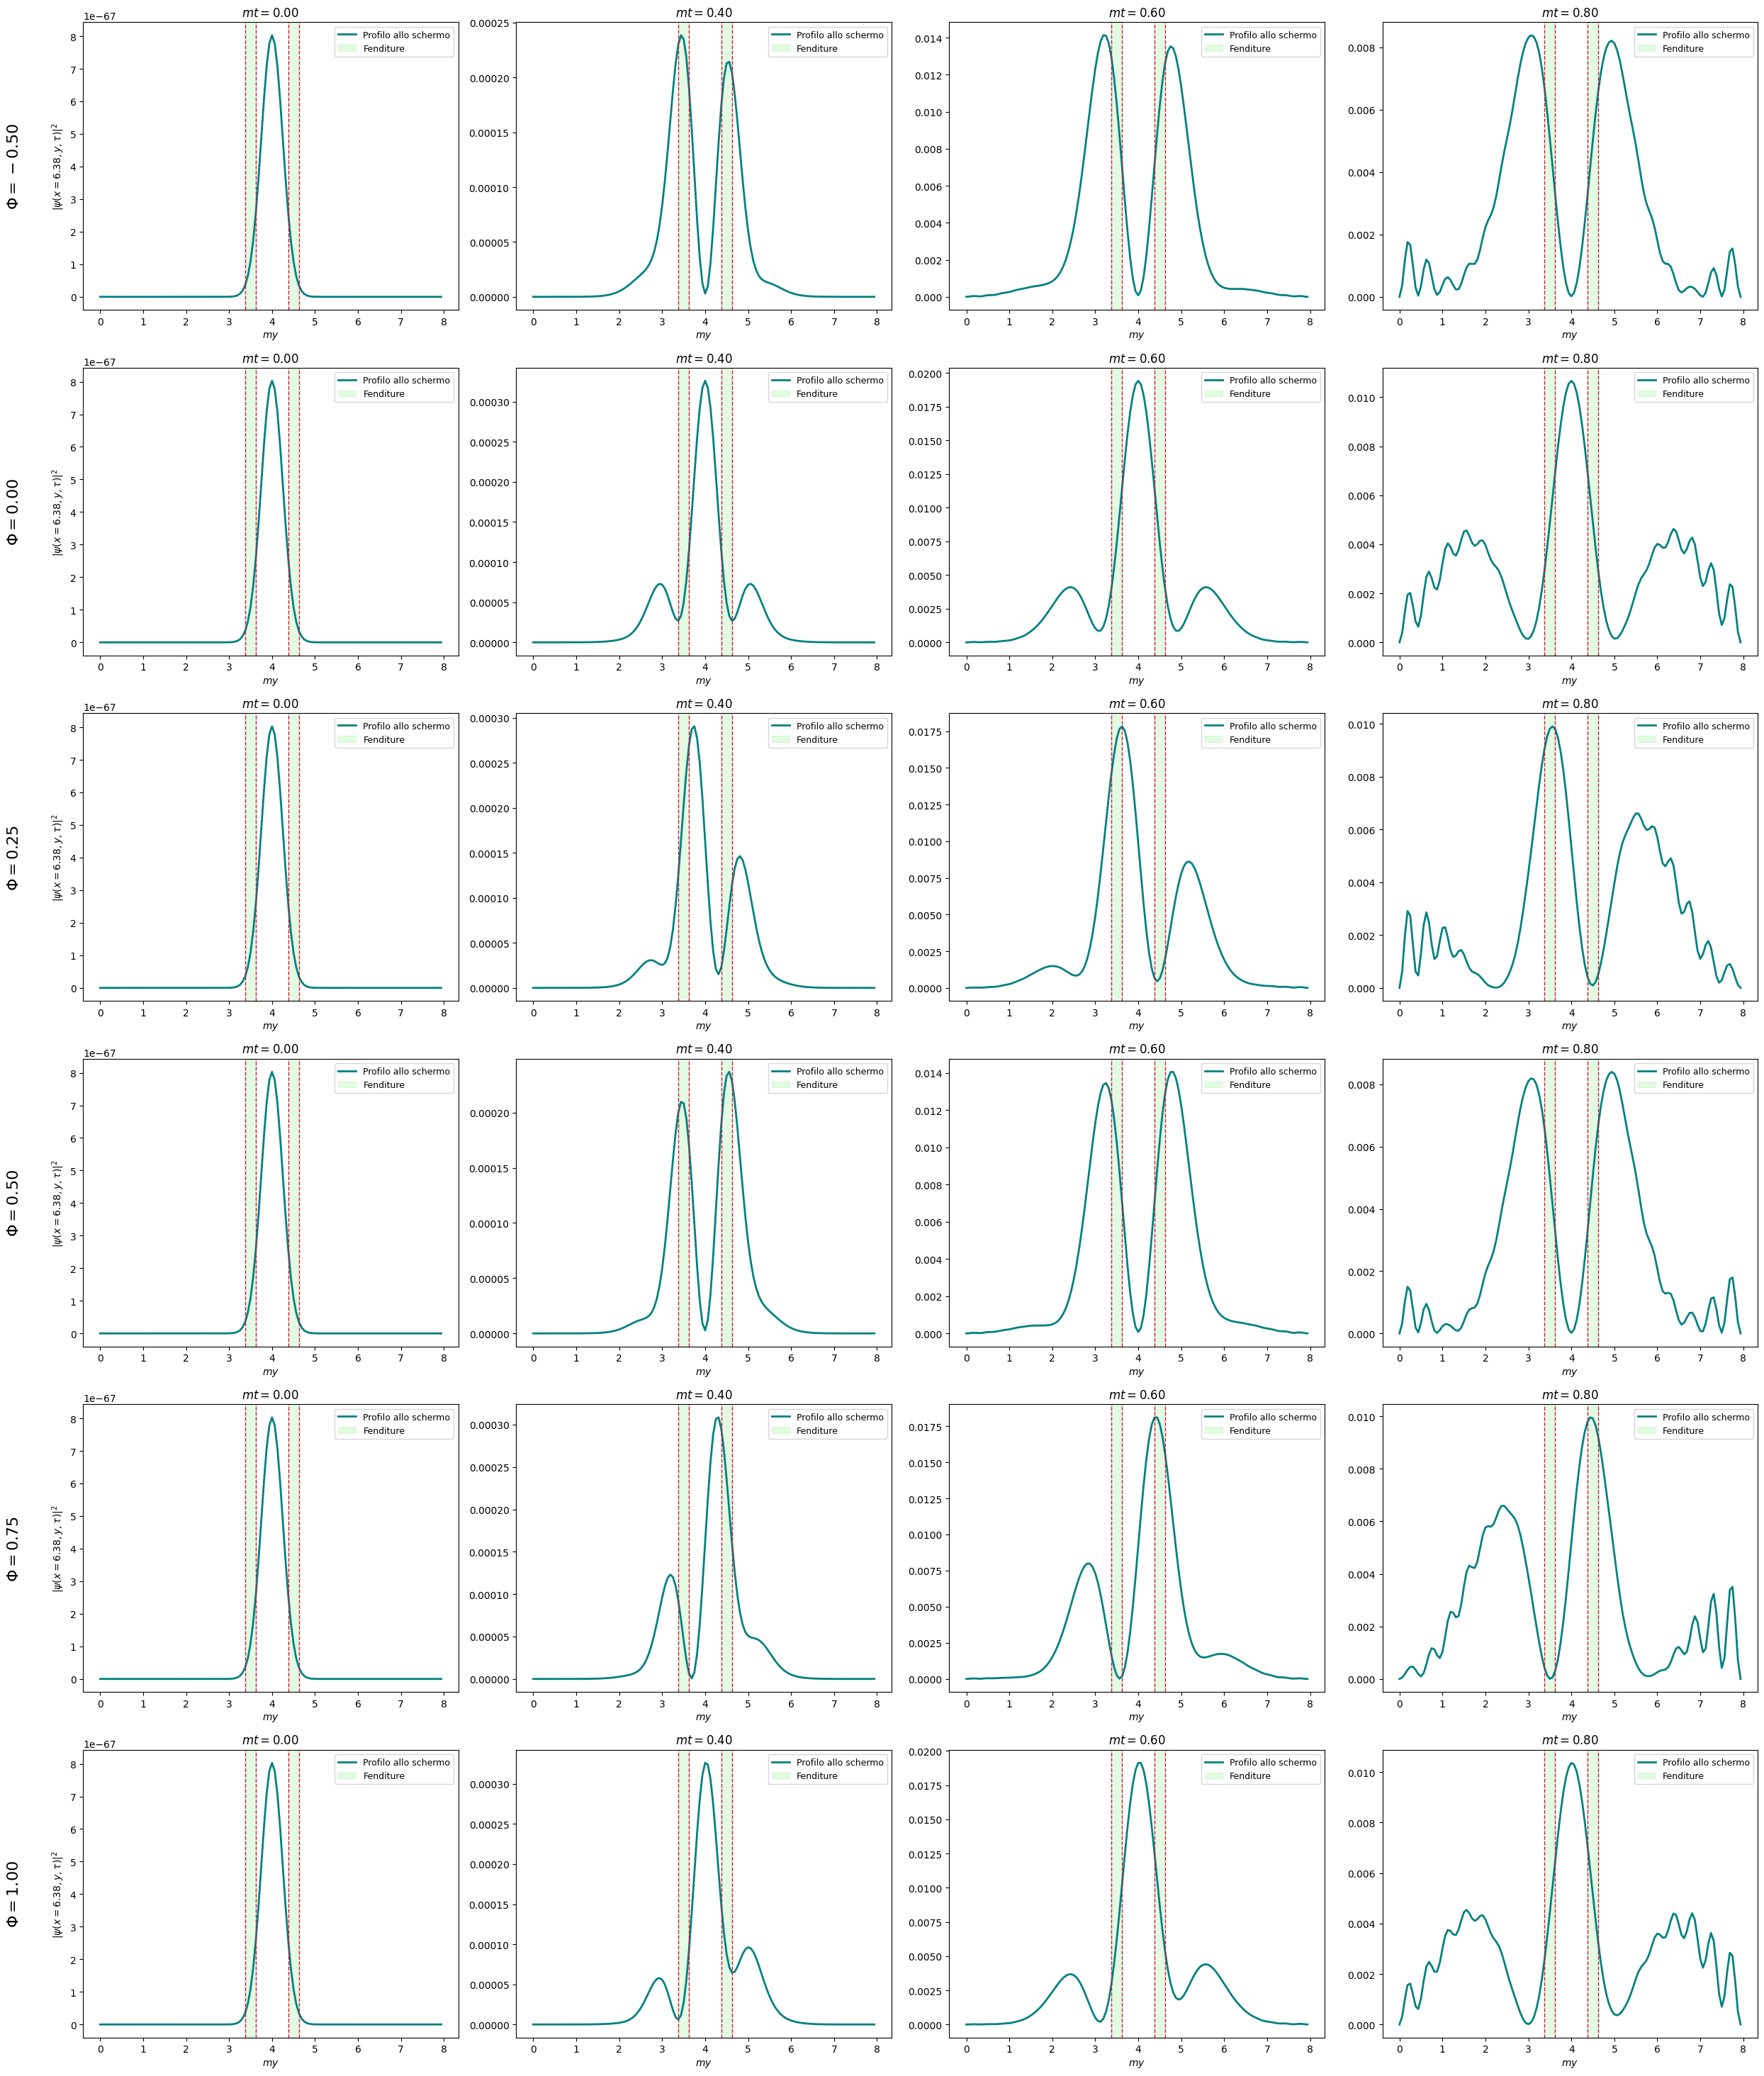

In [71]:
centro_y1, centro_y2 = 3.5, 4.5
semi_ampiezza = 2 * delta_y

bordo_inf_f1, bordo_sup_f1 = centro_y1 - semi_ampiezza, centro_y1 + semi_ampiezza
bordo_inf_f2, bordo_sup_f2 = centro_y2 - semi_ampiezza, centro_y2 + semi_ampiezza

x_screen = int(N*0.8)
x_screen_coord = x[x_screen]
print("posizione dello schermo: ", x_screen_coord)

phi_values = [-0.5, 0, 0.25, 0.5, 0.75, 1]

fig, axes = plt.subplots(len(phi_values), 4, figsize=(25, 5 * len(phi_values)))

for row, Phi in enumerate(phi_values) :
    Ax = -Phi * (Y - ys) / r2
    Ay =  Phi * (X - xs) / r2
    A2 = Ax**2 + Ay**2
    H_m_wrapped = lambda t, phi: -1j * H_m(apply_bc(phi), V, a, Ax, Ay, A2)
    t_values, psi_values = RK4(delta_tau, t_in, phi0_norm, H_m_wrapped, n_step)

    psi_square = np.abs(psi_values) ** 2
    
    for col, t_target in enumerate(times_to_plot):

        ax = axes[row, col]

        idx = np.argmin(np.abs(t_values - t_target))
        frame = psi_square[idx].reshape(N, N)

        density_y = frame[:, x_screen]
        
        ax.plot(y, density_y, color='teal', lw=2, label='Profilo allo schermo')
        ax.axvspan(bordo_inf_f1, bordo_sup_f1, color='lightgreen', alpha=0.25, label='Fenditure')
        ax.axvspan(bordo_inf_f2, bordo_sup_f2, color='lightgreen', alpha=0.25)
        for edge in [bordo_inf_f1, bordo_sup_f1, bordo_inf_f2, bordo_sup_f2]:
            ax.axvline(edge, color='crimson', linestyle='--', lw=1)

        ax.set_title(f"$mt = {t_values[idx]:.2f}$")
        ax.set_xlabel("$my$")
       
        if col == 0:
            ax.set_ylabel(fr"$|\psi(x={x_screen_coord:.2f}, y, \tau)|^2$")
            ax.annotate(
                fr'$\Phi = {Phi:.2f}$',
                xy=(0, 0.5), xycoords='axes fraction',
                xytext=(-70, 0), textcoords='offset points',
                ha='center', va='center', fontsize=16, fontweight='bold', rotation=90
            )
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

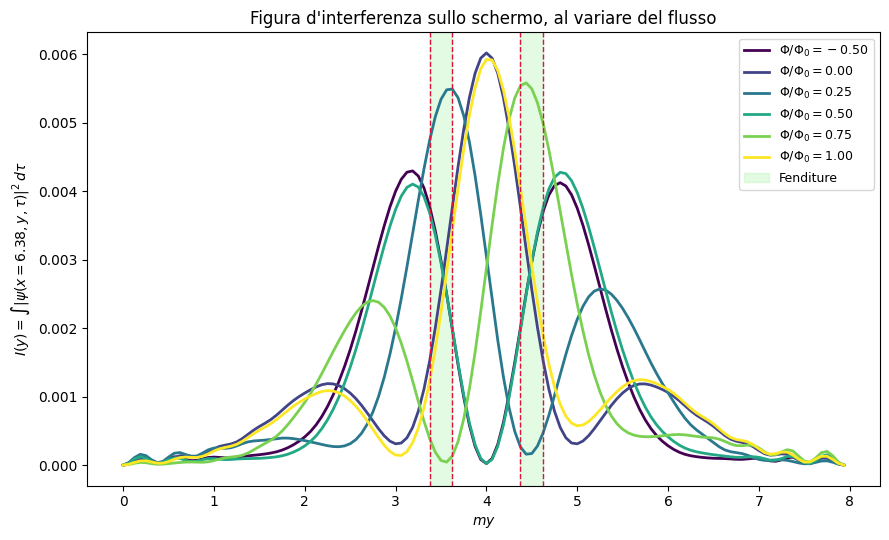

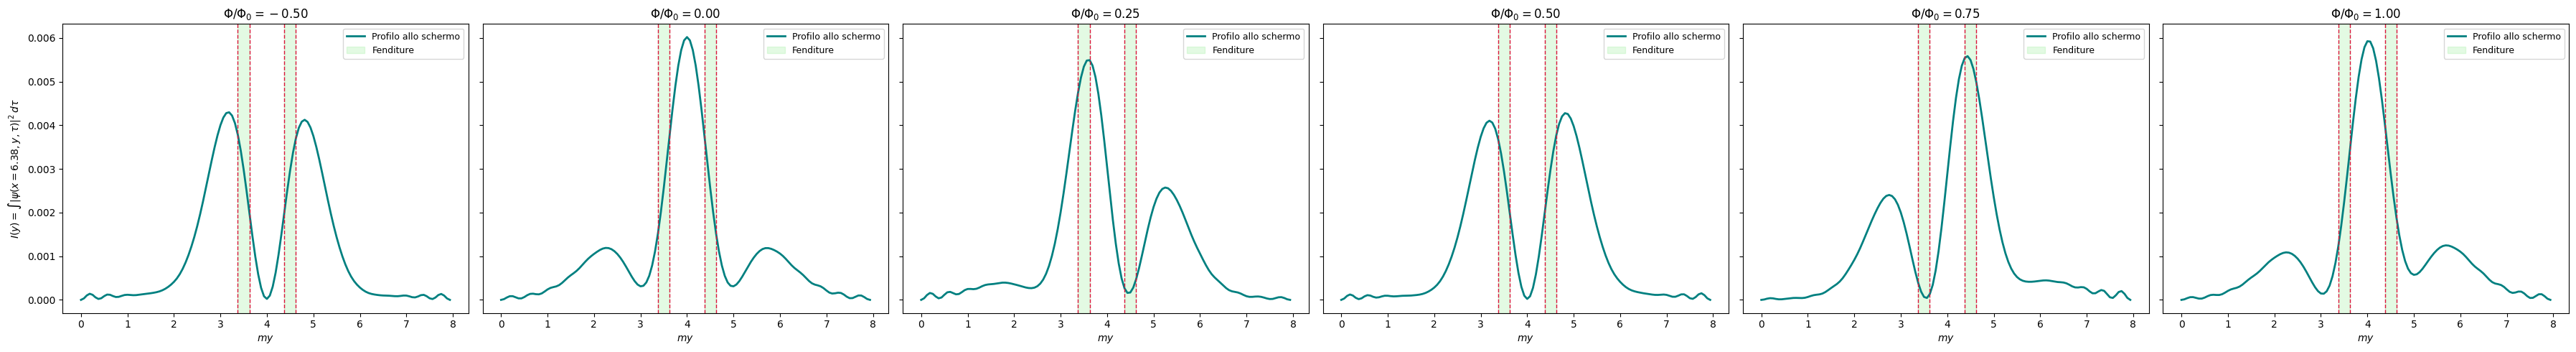

In [61]:
schermo = {}                                 

for Phi in phi_values:
    Ax = -Phi * (Y - ys) / r2
    Ay =  Phi * (X - xs) / r2
    A2 = Ax**2 + Ay**2
    H_m_wrapped = lambda t, phi: -1j * H_m(apply_bc(phi), V, a, Ax, Ay, A2)
    t_values, psi_values = RK4(delta_tau, t_in, phi0_norm, H_m_wrapped, n_step)

    psi_square = np.abs(psi_values) ** 2
    schermo[Phi] = psi_square[:, :, x_screen].sum(axis=0) * delta_tau


fig, ax = plt.subplots(figsize=(9, 5.5))
colori = plt.cm.viridis(np.linspace(0, 1, len(phi_values)))
for Phi, col in zip(phi_values, colori):
    ax.plot(y, schermo[Phi], color=col, lw=2, label=fr'$\Phi/\Phi_0={Phi:.2f}$')
ax.axvspan(bordo_inf_f1, bordo_sup_f1, color='lightgreen', alpha=0.25, label='Fenditure')
ax.axvspan(bordo_inf_f2, bordo_sup_f2, color='lightgreen', alpha=0.25)
for edge in [bordo_inf_f1, bordo_sup_f1, bordo_inf_f2, bordo_sup_f2]:
    ax.axvline(edge, color='crimson', linestyle='--', lw=1)
ax.set_xlabel("$my$")
ax.set_ylabel(fr"$I(y)=\int|\psi(x={x_screen_coord:.2f}, y, \tau)|^2\,d\tau$")
ax.set_title("Figura d'interferenza sullo schermo, al variare del flusso")
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(phi_values), figsize=(6 * len(phi_values), 5), sharey=True)
for ax, Phi in zip(axes, phi_values):
    ax.plot(y, schermo[Phi], color='teal', lw=2, label='Profilo allo schermo')
    ax.axvspan(bordo_inf_f1, bordo_sup_f1, color='lightgreen', alpha=0.25, label='Fenditure')
    ax.axvspan(bordo_inf_f2, bordo_sup_f2, color='lightgreen', alpha=0.25)
    for edge in [bordo_inf_f1, bordo_sup_f1, bordo_inf_f2, bordo_sup_f2]:
        ax.axvline(edge, color='crimson', linestyle='--', lw=1)
    ax.set_title(fr"$\Phi/\Phi_0 = {Phi:.2f}$")
    ax.set_xlabel("$my$")
    if ax is axes[0]:
        ax.set_ylabel(fr"$I(y)=\int|\psi(x={x_screen_coord:.2f}, y, \tau)|^2\,d\tau$")
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

Interfrangia misurata (dai picchi) = 1.5625

Phi/Phi0 = 0.250
y_picco misurato = 3.6250  (y0 = 4.0000)
shift misurato  = +0.3750
shift teorico (da Lambda misurata) = +0.3906

Phi/Phi0 = 0.750
y_picco misurato = 4.4375  (y0 = 4.0000)
shift misurato  = +0.4375
shift teorico (da Lambda misurata) = +0.3906

Phi/Phi0 = 1.000
y_picco misurato = 4.0000  (y0 = 4.0000)
shift misurato  = +0.0000
shift teorico (da Lambda misurata) = +0.0000


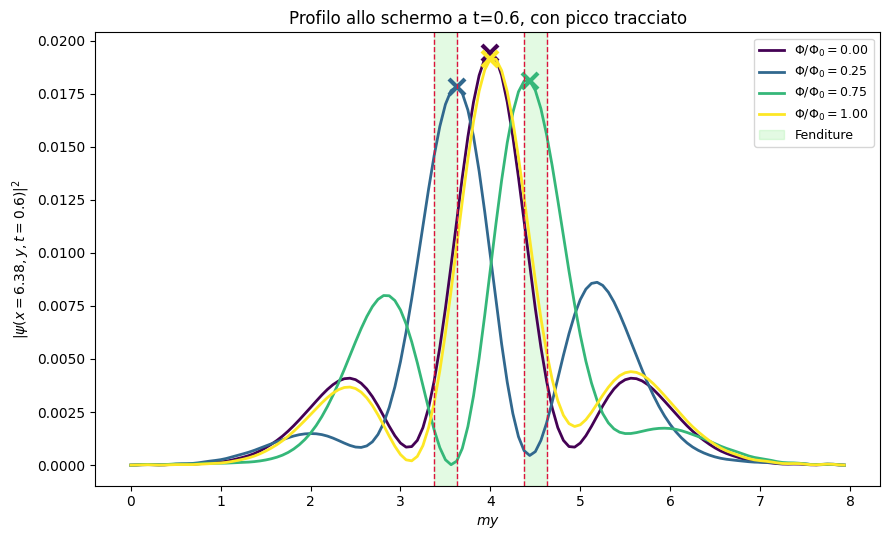

In [ ]:
from scipy.signal import find_peaks

t_target = 0.6

phi_da_plottare = [0.0, 0.25, 0.75, 1]
density_y_dict = {}

for Phi in phi_da_plottare:
    Ax = -Phi * (Y - ys) / r2
    Ay =  Phi * (X - xs) / r2
    A2 = Ax**2 + Ay**2
    H_m_wrapped = lambda t, phi: -1j * H_m(apply_bc(phi), V, a, Ax, Ay, A2)
    t_values, psi_values = RK4(delta_tau, t_in, phi0_norm, H_m_wrapped, n_step)

    psi_square = np.abs(psi_values) ** 2

    idx_t = np.argmin(np.abs(t_values - t_target))
    density_y_dict[Phi] = psi_square[idx_t, :, x_screen]

#riferimento a phi=0
idx0, _ = find_peaks(density_y_dict[0.0], prominence=0.05*density_y_dict[0.0].max())
y0_peaks = y[idx0]
I0_peaks = density_y_dict[0.0][idx0]
y0_top = y0_peaks[np.argmax(I0_peaks)]

passo_frangia = np.mean(np.diff(y0_peaks))
print(f"Interfrangia misurata (dai picchi) = {passo_frangia:.4f}")

picchi_trovati = {0.0: y0_top}

for Phi in [0.25, 0.75, 1]:
    I = density_y_dict[Phi]
    idx, _ = find_peaks(I, prominence=0.05*I.max())
    yi_peaks = y[idx]
    y_top = yi_peaks[np.argmin(np.abs(yi_peaks - y0_top))]
    picchi_trovati[Phi] = y_top

    shift_misurato = abs(y_top - y0_top)

    shift_teorico_da_misura = abs(Phi * passo_frangia)
    shift_teorico_da_misura_wrapped = min(shift_teorico_da_misura % passo_frangia, passo_frangia - shift_teorico_da_misura % passo_frangia)

    print("")
    print(f"Phi/Phi0 = {Phi:.3f}")
    print(f"y_picco misurato = {y_top:.4f}  (y0 = {y0_top:.4f})")
    print(f"shift misurato  = {shift_misurato:+.4f}")
    print(f"shift teorico (da Lambda misurata) = {shift_teorico_da_misura_wrapped:+.4f}")


fig, ax = plt.subplots(figsize=(9, 5.5))
colori = plt.cm.viridis(np.linspace(0, 1, len(phi_da_plottare)))
for Phi, col in zip(phi_da_plottare, colori):
    I = density_y_dict[Phi]
    ax.plot(y, I, color=col, lw=2, label=fr'$\Phi/\Phi_0={Phi:.2f}$')
    y_top = picchi_trovati[Phi]
    ax.plot(y_top, I[np.argmin(np.abs(y - y_top))], 'x', color=col, ms=12, mew=3)

ax.axvspan(bordo_inf_f1, bordo_sup_f1, color='lightgreen', alpha=0.25, label='Fenditure')
ax.axvspan(bordo_inf_f2, bordo_sup_f2, color='lightgreen', alpha=0.25)
for edge in [bordo_inf_f1, bordo_sup_f1, bordo_inf_f2, bordo_sup_f2]:
    ax.axvline(edge, color='crimson', linestyle='--', lw=1)

ax.set_xlabel("$my$")
ax.set_ylabel(fr"$|\psi(x={x_screen_coord:.2f}, y, t={t_target})|^2$")
ax.set_title(f"Profilo allo schermo a t={t_target}")
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()